In [8]:
import pandas as pd
import plotly.express as px
from groq import Groq
from dotenv import load_dotenv
import os

In [9]:
load_dotenv()
client = Groq(api_key=os.getenv("GROQ_API_KEY"))
print("Setup complete!")

Setup complete!


In [10]:
df = pd.read_csv("agency_projects.csv")
df.head()

,Project_Code,Brand,Unit,Project_Type,Category,Project_Manager,Team_Members,Team_Size,Start_Date,End_Date,Month,Planned_Duration_Days,Actual_Duration_Days,Delay_Days,Status,Status_Reason,Revision_Count,Last_Revision_Date,Revision_Reason,Client_Approval_Status
0,PRJ-1000,بانک ملت,استراتژی,تک سفارش,برندینگ,حسین موسوی,"علی رضایی, یاسمن طاهری",2,12/25/2024,1/11/2025,دی,16,17.0,1,انجام‌شده,NaN,1,1/7/2025,تغییر نور,تایید نهایی
1,PRJ-1001,ایرانسل,آتلیه,تک سفارش,فیلم‌برداری,سارا احمدی,"مریم کریمی, کیان مرادی, زهرا نوری, امیر صادقی",4,8/10/2024,8/26/2024,شهریور,13,16.0,3,انجام‌شده,NaN,1,8/12/2024,تغییر موسیقی,تایید نهایی
2,PRJ-1002,پالادیوم,آتلیه,کمپین,تدوین,سارا احمدی,"بهنام عزیزی, یاسمن طاهری, رضا اکبری",3,9/22/2024,NaN,مهر,24,NaN,1,در حال انجام,NaN,1,9/27/2024,تغییر فونت,تایید اولیه
3,PRJ-1003,همراه اول,اینسایت,تک سفارش,تحقیق مصرف‌کننده,حسین موسوی,"حسین موسوی, یاسمن طاهری, نگار حسینی",3,3/15/2025,NaN,فروردین,5,NaN,0,هولدشده,تاخیر در تایید برند,0,NaN,NaN,تایید نشده
4,PRJ-1004,دیوار,خلاقیت,تک سفارش,ایده‌پردازی,کیان مرادی,"امیر صادقی, بهنام عزیزی",2,4/18/2024,4/26/2024,اردیبهشت,4,8.0,4,انجام‌شده,NaN,0,NaN,NaN,تایید نهایی


In [11]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())

Shape: (600, 20)

Columns: ['Project_Code', 'Brand', 'Unit', 'Project_Type', 'Category', 'Project_Manager', 'Team_Members', 'Team_Size', 'Start_Date', 'End_Date', 'Month', 'Planned_Duration_Days', 'Actual_Duration_Days', 'Delay_Days', 'Status', 'Status_Reason', 'Revision_Count', 'Last_Revision_Date', 'Revision_Reason', 'Client_Approval_Status']

Missing values:
Project_Code                0
Brand                       0
Unit                        0
Project_Type                0
Category                    0
Project_Manager             0
Team_Members                0
Team_Size                   0
Start_Date                  0
End_Date                  221
Month                       0
Planned_Duration_Days       0
Actual_Duration_Days      221
Delay_Days                  0
Status                      0
Status_Reason             504
Revision_Count              0
Last_Revision_Date        375
Revision_Reason           375
Client_Approval_Status      0
dtype: int64


Unit
استراتژی    154
اینسایت     152
آتلیه       151
خلاقیت      143
Name: count, dtype: int64


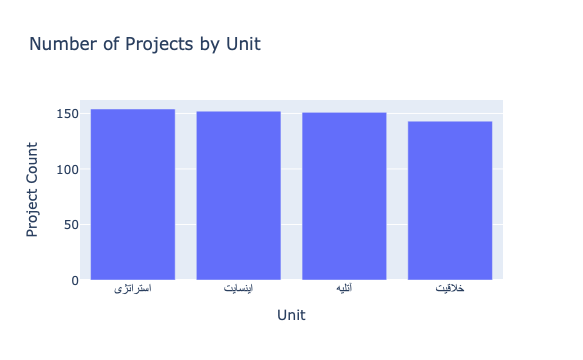

In [14]:
unit_counts = df['Unit'].value_counts()
print(unit_counts)

fig = px.bar(
    x=unit_counts.index,
    y=unit_counts.values,
    title="Number of Projects by Unit",
    labels={'x': 'Unit', 'y': 'Project Count'}
)
fig.show()

Unit
خلاقیت      4.237762
آتلیه       3.781457
استراتژی    3.019481
اینسایت     1.835526
Name: Delay_Days, dtype: float64


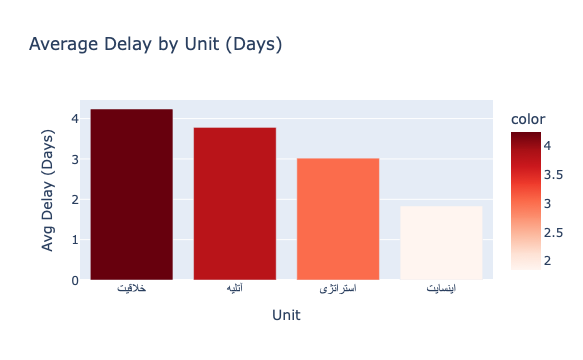

In [15]:
delay_by_unit = df.groupby('Unit')['Delay_Days'].mean().sort_values(ascending=False)
print(delay_by_unit)

fig = px.bar(
    x=delay_by_unit.index,
    y=delay_by_unit.values,
    title="Average Delay by Unit (Days)",
    labels={'x': 'Unit', 'y': 'Avg Delay (Days)'},
    color=delay_by_unit.values,
    color_continuous_scale="Reds"
)
fig.show()

Category
طراحی شعار          1.425000
طراحی گرافیک        1.322581
کمپین تبلیغاتی      1.129032
موشن گرافیک         1.037037
برندینگ             1.024390
محتوای دیجیتال      1.000000
ایده‌پردازی         0.947368
فیلم‌برداری         0.882353
موقعیت‌یابی برند    0.864865
تدوین               0.851852
عکاسی               0.593750
تحلیل داده          0.542857
پلن رسانه‌ای        0.365854
گزارش بازار         0.258065
تحقیق بازار         0.228571
پایش رسانه          0.171429
تحقیق مصرف‌کننده    0.098039
Name: Revision_Count, dtype: float64


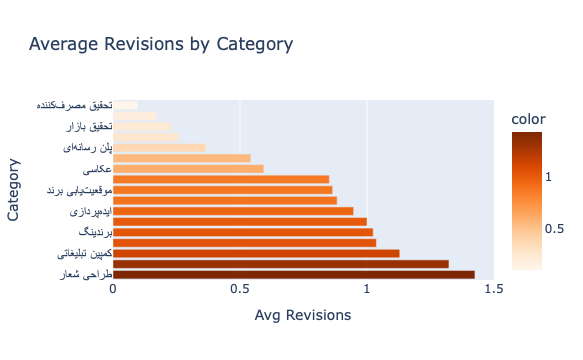

In [16]:
revision_by_category = df.groupby('Category')['Revision_Count'].mean().sort_values(ascending=False)
print(revision_by_category)

fig = px.bar(
    x=revision_by_category.values,
    y=revision_by_category.index,
    orientation='h',
    title="Average Revisions by Category",
    labels={'x': 'Avg Revisions', 'y': 'Category'},
    color=revision_by_category.values,
    color_continuous_scale="Oranges"
)
fig.show()

In [19]:
pip install statsmodels

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 238.8 kB/s eta 0:00:001m324.3 kB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 411.3 kB/s eta 0:00:00m eta 0:00:0136m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 618.4 kB/s eta 0:00:001m627.6 kB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.4/20.4 MB 679.5 kB/s eta 0:00:00m eta 0:00:010:00:01

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


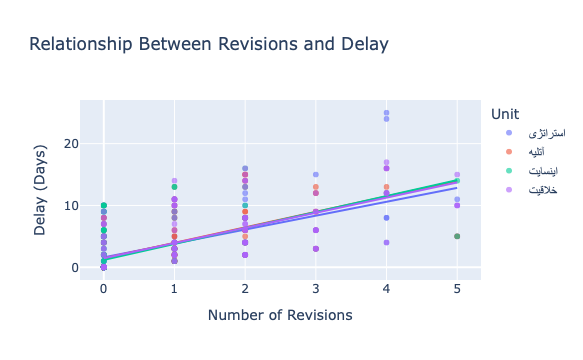

In [23]:
fig = px.scatter(
    df,
    x='Revision_Count',
    y='Delay_Days',
    color='Unit',
    title="Relationship Between Revisions and Delay",
    labels={'Revision_Count': 'Number of Revisions', 'Delay_Days': 'Delay (Days)'},
    opacity=0.6,
    trendline="ols"
)
fig.show()

In [24]:
df_people = df.copy()
df_people['Team_Members'] = df_people['Team_Members'].str.split(', ')
df_people = df_people.explode('Team_Members')
df_people = df_people.rename(columns={'Team_Members': 'Person'})

print(f"Original rows: {len(df)}")
print(f"Exploded rows: {len(df_people)}")
df_people[['Project_Code', 'Person', 'Unit', 'Status']].head(10)

Original rows: 600
Exploded rows: 1839


,Project_Code,Person,Unit,Status
0,PRJ-1000,علی رضایی,استراتژی,انجام‌شده
0,PRJ-1000,یاسمن طاهری,استراتژی,انجام‌شده
1,PRJ-1001,مریم کریمی,آتلیه,انجام‌شده
1,PRJ-1001,کیان مرادی,آتلیه,انجام‌شده
1,PRJ-1001,زهرا نوری,آتلیه,انجام‌شده
1,PRJ-1001,امیر صادقی,آتلیه,انجام‌شده
2,PRJ-1002,بهنام عزیزی,آتلیه,در حال انجام
2,PRJ-1002,یاسمن طاهری,آتلیه,در حال انجام
2,PRJ-1002,رضا اکبری,آتلیه,در حال انجام
3,PRJ-1003,حسین موسوی,اینسایت,هولدشده


In [25]:
person_stats = df_people.groupby('Person').agg(
    Total_Projects=('Project_Code', 'count'),
    Total_Days=('Planned_Duration_Days', 'sum'),
    Avg_Delay=('Delay_Days', 'mean'),
    Completed_Rate=('Status', lambda x: (x == 'انجام‌شده').mean())
).round(2)

person_stats = person_stats.sort_values('Total_Projects', ascending=False)
person_stats

,Total_Projects,Total_Days,Avg_Delay,Completed_Rate
Person,,,,
یاسمن طاهری,138,2461,3.05,0.59
محمد قاسمی,133,2845,3.65,0.55
فاطمه رستمی,129,2890,3.29,0.58
علی رضایی,128,2874,2.88,0.53
امیر صادقی,124,2676,3.02,0.56
بهنام عزیزی,124,2432,2.95,0.64
مریم کریمی,123,2472,3.38,0.54
زهرا نوری,121,2426,3.30,0.53
حسین موسوی,120,2688,2.82,0.56


In [26]:
# Check a specific person's projects
sample_person = person_stats.index[0]
print(f"Checking: {sample_person}")
df_people[df_people['Person'] == sample_person][['Project_Code', 'Planned_Duration_Days', 'Status']]

Checking: یاسمن طاهری


,Project_Code,Planned_Duration_Days,Status
0,PRJ-1000,16,انجام‌شده
2,PRJ-1002,24,در حال انجام
3,PRJ-1003,5,هولدشده
9,PRJ-1009,16,انجام‌شده
12,PRJ-1012,6,کنسل‌شده
...,...,...,...
557,PRJ-1557,13,هولدشده
576,PRJ-1576,19,در حال انجام
585,PRJ-1585,39,انجام‌شده
587,PRJ-1587,43,انجام‌شده


In [27]:
person_stats = df_people.groupby('Person').agg(
    Total_Projects=('Project_Code', 'count'),
    Avg_Project_Duration=('Planned_Duration_Days', 'mean'),
    Avg_Delay=('Delay_Days', 'mean'),
    Completed_Rate=('Status', lambda x: (x == 'انجام‌شده').mean())
).round(2)

person_stats = person_stats.sort_values('Total_Projects', ascending=False)
person_stats

,Total_Projects,Avg_Project_Duration,Avg_Delay,Completed_Rate
Person,,,,
یاسمن طاهری,138,17.83,3.05,0.59
محمد قاسمی,133,21.39,3.65,0.55
فاطمه رستمی,129,22.40,3.29,0.58
علی رضایی,128,22.45,2.88,0.53
امیر صادقی,124,21.58,3.02,0.56
بهنام عزیزی,124,19.61,2.95,0.64
مریم کریمی,123,20.10,3.38,0.54
زهرا نوری,121,20.05,3.30,0.53
حسین موسوی,120,22.40,2.82,0.56


In [28]:
brand_stats = df.groupby('Brand').agg(
    Total_Projects=('Project_Code', 'count'),
    Units_Worked_With=('Unit', 'nunique'),
    Avg_Delay=('Delay_Days', 'mean'),
    Completed_Rate=('Status', lambda x: (x == 'انجام‌شده').mean()),
    Cancelled_Count=('Status', lambda x: (x == 'کنسل‌شده').sum())
).round(2)

brand_stats = brand_stats.sort_values('Total_Projects', ascending=False)
brand_stats

,Total_Projects,Units_Worked_With,Avg_Delay,Completed_Rate,Cancelled_Count
Brand,,,,,
علاءالدین,67,4,3.75,0.51,2
ایرانسل,55,4,3.55,0.58,4
دیوار,55,4,3.05,0.56,5
مای‌کت,54,4,3.13,0.63,2
بانک ملت,53,4,3.43,0.62,3
تپسی,51,4,2.86,0.67,2
دیجی‌کالا,50,4,3.74,0.58,2
رفاه,47,4,3.00,0.53,5
اسنپ,46,4,2.91,0.48,5


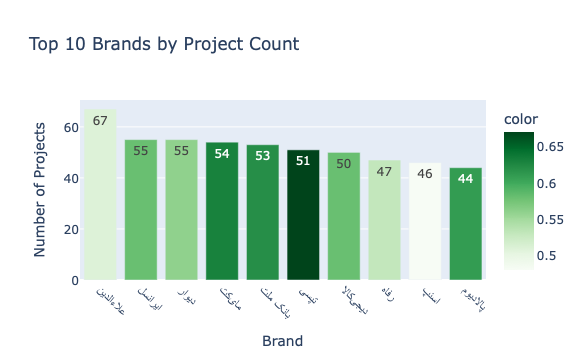

In [29]:
top_brands = brand_stats.head(10)

fig = px.bar(
    x=top_brands.index,
    y=top_brands['Total_Projects'],
    title="Top 10 Brands by Project Count",
    labels={'x': 'Brand', 'y': 'Number of Projects'},
    color=top_brands['Completed_Rate'],
    color_continuous_scale="Greens",
    text=top_brands['Total_Projects']
)
fig.update_xaxes(tickangle=45)
fig.show()

In [30]:
# Normalize each metric to 0-1 scale for fair comparison
brand_stats['Project_Score'] = brand_stats['Total_Projects'] / brand_stats['Total_Projects'].max()
brand_stats['Diversity_Score'] = brand_stats['Units_Worked_With'] / brand_stats['Units_Worked_With'].max()
brand_stats['Quality_Score'] = brand_stats['Completed_Rate']

# Combined Key Account Score
brand_stats['Key_Account_Score'] = (
    brand_stats['Project_Score'] * 0.4 +
    brand_stats['Diversity_Score'] * 0.3 +
    brand_stats['Quality_Score'] * 0.3
).round(2)

key_accounts = brand_stats.sort_values('Key_Account_Score', ascending=False)
key_accounts[['Total_Projects', 'Units_Worked_With', 'Completed_Rate', 'Key_Account_Score']]

,Total_Projects,Units_Worked_With,Completed_Rate,Key_Account_Score
Brand,,,,
علاءالدین,67,4,0.51,0.85
مای‌کت,54,4,0.63,0.81
تپسی,51,4,0.67,0.81
ایرانسل,55,4,0.58,0.80
دیوار,55,4,0.56,0.80
بانک ملت,53,4,0.62,0.80
دیجی‌کالا,50,4,0.58,0.77
پالادیوم,44,4,0.61,0.75
رفاه,47,4,0.53,0.74


In [35]:
def ask_ai(question, context):
    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{
            "role": "user",
            "content": f"""
You are an expert agency operations analyst.

Data context:
{context}

Question: {question}

Give a clear, actionable answer in Persian.
            """
        }],
        max_tokens=800
    )
    return response.choices[0].message.content

# Build context from our analysis
context = f"""
Key Account Scores:
{key_accounts[['Total_Projects', 'Completed_Rate', 'Key_Account_Score']].to_string()}

Unit Delay Analysis:
{delay_by_unit.to_string()}
"""

answer = ask_ai("چرا برند گلرنگ امتیاز پایینی داره و چه پیشنهادی برای بهبود همکاری باهاش داری؟", context)
print(answer)

برند گلرنگ با امتیاز ۰.۶۴، یکی از پایین‌ترین امتیازات را در بین برندهای لیست دارد. برای درک این موضوع و ارائه پیشنهادات برای بهبود همکاری، باید به داده‌های موجود نگاهی بیندازیم.

 primeiro، تعداد پروژه‌های انجام شده توسط گلرنگ با ۳۶ پروژه، یکی از کمترین‌ها در بین برندهای لیست است. این ممکن است به این معنی باشد که گلرنگ moins از سایر برندها با ما合作 می‌کند.

completed_rate گلرنگ نیز با ۰.۴۲، یکی از پایین‌ترین نرخ‌های تکمیل پروژه است. این ممکن است به این معنی باشد که پروژه‌های گلرنگ با تأخیر یا با کیفیت پایین‌تر تمام می‌شود.

با توجه به داده‌های موجود، یک پیشنهاد برای بهبود همکاری با گلرنگ این است که:

۱. افزایش تعداد پروژه‌های ارائه شده به گلرنگ: با توجه به تعداد پروژه‌های کم گلرنگ، می‌توان تلاش کرد تا پروژه‌های بیشتری به آن پیشنهاد شود تا بتواند تجربه و همکاری خود را با ما افزایش دهد.

۲. بهبود مدیریت پروژه برای گلرنگ: با توجه به نرخ تکمیل پایین گلرنگ، می‌توان تلاش کرد تا فرآیندهای مدیریت پروژه را برای آن برند改 thiện کرد. این می‌تواند شامل ارائه آموزش‌ها یا پشتیبانی بیشتر برای تیم مدیری

In [36]:
def get_avatar_url(name):
    """Generate a consistent avatar based on person's name initials."""
    return f"https://api.dicebear.com/7.x/initials/svg?seed={name}"

def get_brand_logo_url(brand):
    """Generate a consistent shape-based logo based on brand name."""
    return f"https://api.dicebear.com/7.x/shapes/svg?seed={brand}"

# Test it
sample_person = person_stats.index[0]
sample_brand = key_accounts.index[0]

print(f"Avatar for {sample_person}:")
print(get_avatar_url(sample_person))
print(f"\nLogo for {sample_brand}:")
print(get_brand_logo_url(sample_brand))

Avatar for یاسمن طاهری:
https://api.dicebear.com/7.x/initials/svg?seed=یاسمن طاهری

Logo for علاءالدین:
https://api.dicebear.com/7.x/shapes/svg?seed=علاءالدین


In [37]:
from IPython.display import Image, display

print(f"Avatar for {sample_person}:")
display(Image(url=get_avatar_url(sample_person)))

print(f"\nLogo for {sample_brand}:")
display(Image(url=get_brand_logo_url(sample_brand)))

Avatar for یاسمن طاهری:



Logo for علاءالدین:


In [38]:
top_people = person_stats.head(5)

for person, row in top_people.iterrows():
    print(f"\n{person}")
    print(f"  Projects: {row['Total_Projects']} | Avg Delay: {row['Avg_Delay']} days | Completion Rate: {row['Completed_Rate']:.0%}")
    display(Image(url=get_avatar_url(person), width=60))


یاسمن طاهری
  Projects: 138.0 | Avg Delay: 3.05 days | Completion Rate: 59%



محمد قاسمی
  Projects: 133.0 | Avg Delay: 3.65 days | Completion Rate: 55%



فاطمه رستمی
  Projects: 129.0 | Avg Delay: 3.29 days | Completion Rate: 58%



علی رضایی
  Projects: 128.0 | Avg Delay: 2.88 days | Completion Rate: 53%



امیر صادقی
  Projects: 124.0 | Avg Delay: 3.02 days | Completion Rate: 56%


In [39]:
top_brands_list = key_accounts.head(5)

for brand, row in top_brands_list.iterrows():
    print(f"\n{brand}")
    print(f"  Projects: {row['Total_Projects']} | Completion Rate: {row['Completed_Rate']:.0%} | Key Account Score: {row['Key_Account_Score']}")
    display(Image(url=get_brand_logo_url(brand), width=60))


علاءالدین
  Projects: 67.0 | Completion Rate: 51% | Key Account Score: 0.85



مای‌کت
  Projects: 54.0 | Completion Rate: 63% | Key Account Score: 0.81



تپسی
  Projects: 51.0 | Completion Rate: 67% | Key Account Score: 0.81



ایرانسل
  Projects: 55.0 | Completion Rate: 58% | Key Account Score: 0.8



دیوار
  Projects: 55.0 | Completion Rate: 56% | Key Account Score: 0.8
